# Домашнее Задание

In [405]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Ridge
import sklearn.preprocessing as ppc
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [406]:
RANDOM_STATE = 69

np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

## Logistic Regression (Своими Силами)

1. Дописать код градиентного спуска ниже
2. Поиграться с датасетом, предложеннным выше
3. Построить свою версию Логистической регресии (на каком-то одном числовом факторе без пропусков), сравнить результаты с LogisticRegression из SKlearn (Оценить метрики - ROC AUC, подобрать порог и Построить Confusion Matrix, а так же производные метрики от неё )
4. Заполнить пропуски, обработать категориальные переменные, обучить свою версию модели и Logistic Regression, сравнить качество между ними (см п.3) + с моделями из п.3 (как добавление бОльшего количества факторов влияет на качество модели)
5. *Поиграться с нормировкой данных (sklearn.model_selection.StandardScaler) оценить эффект на веса модели и её качество
6. Разбить факторы на Клиентские/Продуктовые/Кредитная История и построить по одной модели на каждом факторе. Затем построить мета-модель (интегральная модель) на трёх факторах - скорах метамоделях (дрейверы) - Сравнить результаты по каждому из драйеров + интегральной модели с одной моделью на всём факторном прстранстве.
7. *Привести график качества (ROC AUC) модели на фиксированной тренировочной выборке в зависимости от количества наблюдений, которые используются при обучении (train выборка). Например: 100, 500, 1000 и тд.

*- задания со звёздочкой, не обязательно, но довольно интересные

## данные

In [407]:
df = pd.read_csv("../../assets/loan_data.csv")
target_col = "loan_status"

In [408]:
df.loc[np.random.choice(range(df.shape[0]), 1000), "person_age"] = np.nan
df.loc[df[df["loan_intent"] == "EDUCATION"].sample(3000).index, "person_income"] = (
    np.nan
)

## функции

In [409]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def logloss(y, p):
    return -(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15)).mean()

In [410]:
class MyLogisticRegression:
    def __init__(self, lr=1e-4, bias=True):
        self.bias = bool(bias)
        self.weights = None
        self.lr = lr

    def preproc_x(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X]) if self.bias else X

    def fit(self, X, y, c_epoch=1000):
        self.weights = np.ones(X.shape[1] + self.bias)

        self.X = self.preproc_x(X)
        self.y = y

        for i in range(c_epoch):
            ids = list(range(self.X.shape[0]))
            np.random.shuffle(ids)

            for j in ids:
                p = sigmoid(np.dot(self.X[j], self.weights))
                grad = (p - self.y[j]) * self.X[j]
                self.weights -= self.lr * grad

            p = sigmoid(self.X @ self.weights)

            if i % 50 == 0:
                print(i, "logloss:", logloss(self.y, p))

    def predict_proba(self, X):
        X = self.preproc_x(X)
        return sigmoid((X @ self.weights) * 1)

    def predict(self, X):
        X = self.preproc_x(X)
        preds = (sigmoid((X @ self.weights) * 1) > 0.5).astype(int)
        preds[preds == 0] = -1
        return preds

In [411]:
def plot_confusion_matrix(y_true, y_proba, thresholds=0.5, label=None):
    if isinstance(thresholds, (float, int)):
        thresholds = [thresholds]

    n = len(thresholds)
    _, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    if n == 1:
        axes = [axes]

    for i, threshold in enumerate(thresholds):
        y_pred = (y_proba >= threshold).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        print(f"\n=== Threshold: {threshold:.2f} ===")
        print("Confusion Matrix:")
        print(cm)
        print(f"Accuracy:  {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall:    {rec:.3f}")
        print(f"F1 Score:  {f1:.3f}")

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"],
            ax=axes[i],
        )

        title = f"{label + ' ' if label else ''}Threshold = {threshold:.2f}"
        axes[i].set_title(title)
        axes[i].set_ylabel("True label")
        axes[i].set_xlabel("Predicted label")

    plt.tight_layout()
    plt.show()

In [412]:
def plot_roc_auc(y_true, y_proba, model_name="Model"):
    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [413]:
def create_split_data(train, test, target_col, include_features: list = None):
    if include_features is not None:
        X_train = train[include_features]
        y_train = train[target_col].values

        X_test = test[include_features]
        y_test = test[target_col].values

    else:
        X_train = train.drop(target_col, axis=1)
        y_train = train[target_col].values

        X_test = test.drop(target_col, axis=1)
        y_test = test[target_col].values

    return X_train, y_train, X_test, y_test

In [414]:
def plot_metrics(y_true, y_proba):
    thresholds = np.linspace(0, 1, 200)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred))

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions, label="Precision", color="blue")
    plt.plot(thresholds, recalls, label="Recall", color="green")
    plt.plot(thresholds, f1s, label="F1 Score", color="red")

    # Максимумы
    best_f1_idx = np.argmax(f1s)
    print(f"Optimal threshold for F1 Score: {thresholds[best_f1_idx]:.2f}")
    plt.axvline(
        thresholds[best_f1_idx],
        linestyle="--",
        color="gray",
        label=f"Best F1 = {thresholds[best_f1_idx]:.2f}",
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision, Recall & F1 Score vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [415]:
def build_pipe(data: pd.DataFrame) -> Pipeline:
    categorical_cols = data.select_dtypes(
        include=[
            "object",
            "category",
        ]
    ).columns.tolist()

    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="mean")),
                                    ("scaler", ppc.StandardScaler()),
                                    (
                                        "transformer",
                                        ppc.SplineTransformer(
                                            n_knots=7,
                                            degree=7,
                                            order="F",
                                            extrapolation="linear",
                                        ),
                                    ),
                                ]
                            ),
                            num_cols,
                        ),
                        (
                            "cat",
                            Pipeline(
                                steps=[
                                    (
                                        "encoder",
                                        ppc.OneHotEncoder(handle_unknown="ignore"),
                                    )
                                ]
                            ),
                            categorical_cols,
                        ),
                    ]
                ),
            ),
            ("poly", ppc.PolynomialFeatures(2)),
        ]
    )

In [416]:
def build_model(X_train, y_train, X_test, y_test):
    clf = Pipeline(
        steps=[
            ("preprocessor", build_pipe(data=X_train)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=500,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    ra_score = roc_auc_score(y_test, proba)

    return clf, ra_score, proba

## логистическая регрессия на одном числовом факторе

In [417]:
train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

X_train, y_train, X_test, y_test = create_split_data(
    train,
    test,
    target_col,
    include_features=["loan_int_rate"],
)

In [418]:
my_lr = MyLogisticRegression()
sk_lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=500,
)

my_lr.fit(X_train, y_train, c_epoch=500)
sk_lr.fit(X_train, y_train)

0 logloss: 0.6194378918964434
50 logloss: 0.47819345863892515
100 logloss: 0.4741445767707961
150 logloss: 0.47234582553835486
200 logloss: 0.4735752299357046
250 logloss: 0.4753395655507383
300 logloss: 0.4719709642385101
350 logloss: 0.47297288819210886
400 logloss: 0.4735325211525493
450 logloss: 0.47387248125756093


LogisticRegression(max_iter=500, random_state=69)

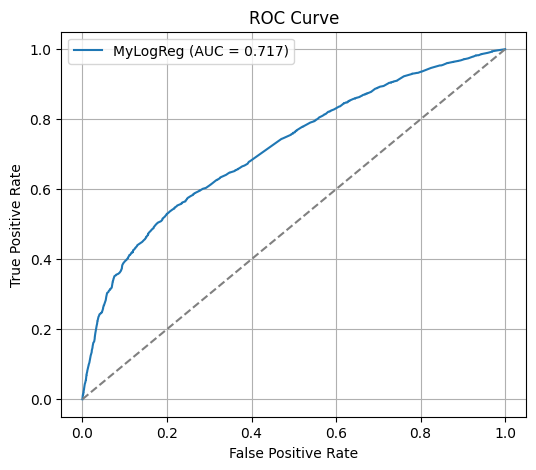

Optimal threshold for F1 Score: 0.25


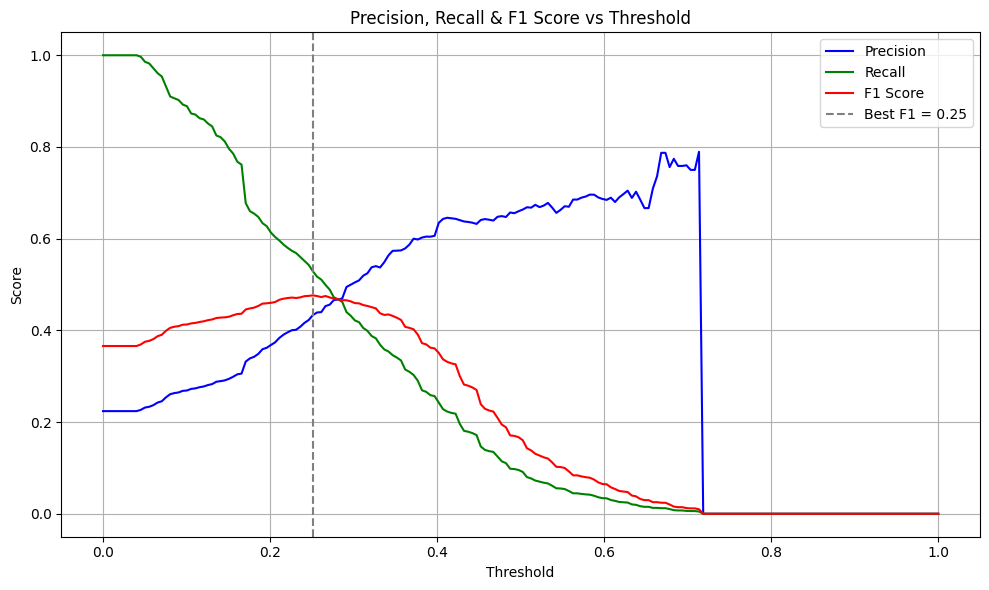

In [419]:
my_proba = my_lr.predict_proba(X_test)
plot_roc_auc(y_test, my_proba, model_name="MyLogReg")
plot_metrics(y_test, my_proba)

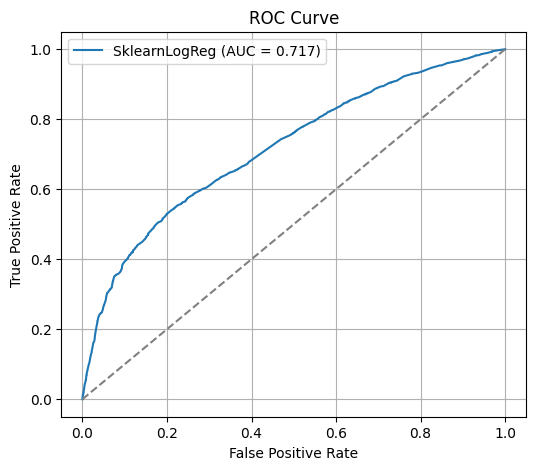

Optimal threshold for F1 Score: 0.28


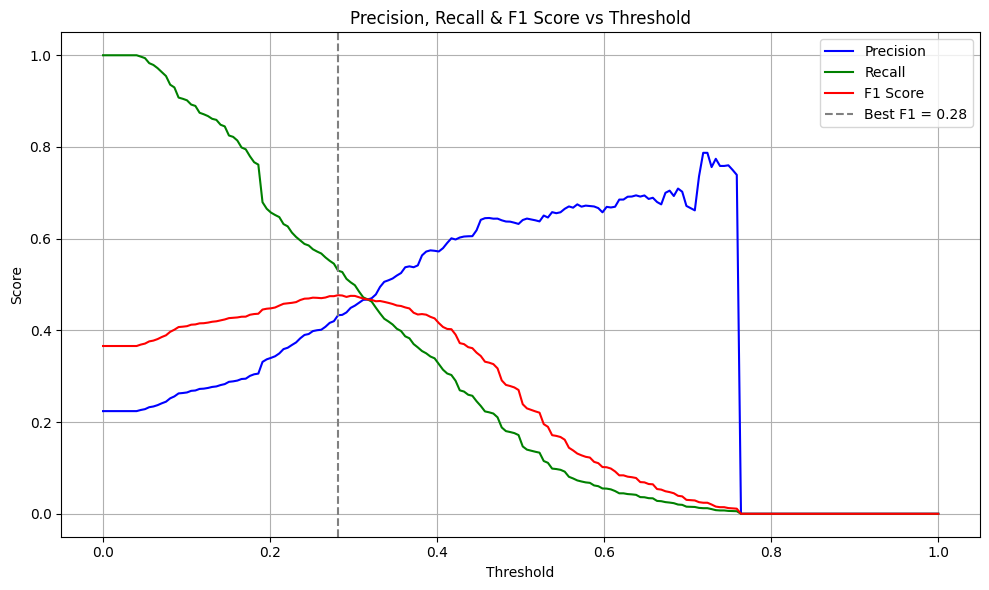

In [420]:
sk_proba = sk_lr.predict_proba(X_test)[:, 1]
plot_roc_auc(y_test, sk_proba, model_name="SklearnLogReg")
plot_metrics(y_test, sk_proba)


=== Threshold: 0.25 ===
Confusion Matrix:
[[8378 2099]
 [1420 1603]]
Accuracy:  0.739
Precision: 0.433
Recall:    0.530
F1 Score:  0.477

=== Threshold: 0.28 ===
Confusion Matrix:
[[8857 1620]
 [1606 1417]]
Accuracy:  0.761
Precision: 0.467
Recall:    0.469
F1 Score:  0.468


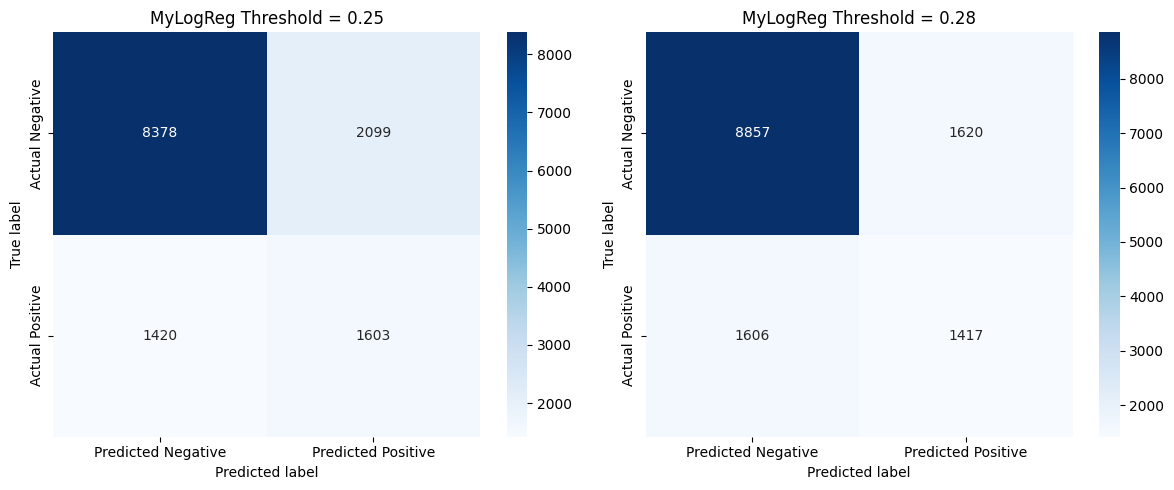


=== Threshold: 0.25 ===
Confusion Matrix:
[[7807 2670]
 [1271 1752]]
Accuracy:  0.708
Precision: 0.396
Recall:    0.580
F1 Score:  0.471

=== Threshold: 0.28 ===
Confusion Matrix:
[[8372 2105]
 [1420 1603]]
Accuracy:  0.739
Precision: 0.432
Recall:    0.530
F1 Score:  0.476


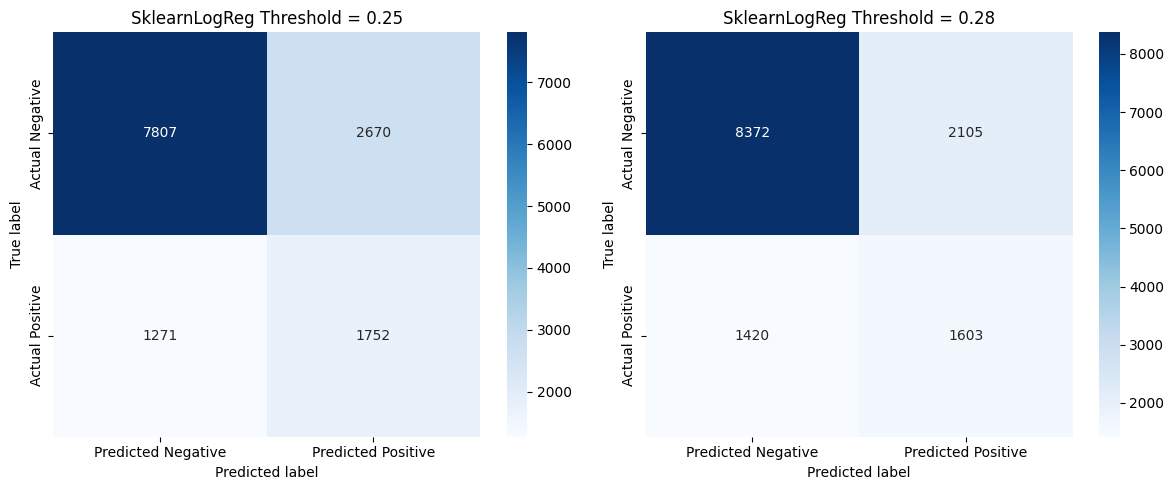

In [421]:
thresholds = [0.25, 0.28]
plot_confusion_matrix(y_test, my_proba, thresholds=thresholds, label="MyLogReg")
plot_confusion_matrix(y_test, sk_proba, thresholds=thresholds, label="SklearnLogReg")

## логистическая регрессия на множестве фичей с обработками

In [422]:
X_train, y_train, X_test, y_test = create_split_data(train, test, target_col)

In [423]:
def find_high_corr_cols(df: pd.DataFrame, threshold: float = 0.75) -> pd.DataFrame:
    corr_matrix = df.corr(numeric_only=True)
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append(
                    (
                        corr_matrix.columns[i],
                        corr_matrix.columns[j],
                        corr_matrix.iloc[i, j],
                    )
                )

    high_corr_df = pd.DataFrame(
        high_corr_pairs,
        columns=[
            "Feature 1",
            "Feature 2",
            "Correlation",
        ],
    )
    high_corr_df = high_corr_df.sort_values("Correlation", ascending=False)

    return high_corr_df

In [424]:
df_high_corr = find_high_corr_cols(X_train, threshold=0.6)

print(df_high_corr)

X_train = X_train.drop(columns=df_high_corr["Feature 2"].to_list(), axis=1)
X_test = X_test.drop(columns=df_high_corr["Feature 2"].to_list(), axis=1)

        Feature 1                   Feature 2  Correlation
0      person_age              person_emp_exp     0.953481
1      person_age  cb_person_cred_hist_length     0.863661
2  person_emp_exp  cb_person_cred_hist_length     0.825695


In [425]:
pipe = build_pipe(data=X_train)

In [426]:
X_train_processed = pipe.fit_transform(X_train)
X_test_processed = pipe.transform(X_test)

In [427]:
my_lr = MyLogisticRegression()
sk_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=500)

my_lr.fit(X_train_processed, y_train, c_epoch=500)
sk_lr.fit(X_train_processed, y_train)

0 logloss: 26.888711540710936
50 logloss: 0.2434662007706262
100 logloss: 0.21783313019057024
150 logloss: 0.20925549701476526
200 logloss: 0.20406383830113795
250 logloss: 0.20023828785960499
300 logloss: 0.19718233085213757
350 logloss: 0.19473212996548728
400 logloss: 0.1925632782447392
450 logloss: 0.19080770661802446


LogisticRegression(max_iter=500, random_state=69)

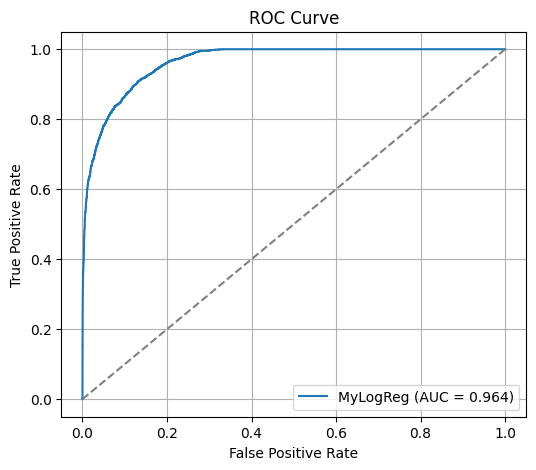

Optimal threshold for F1 Score: 0.46


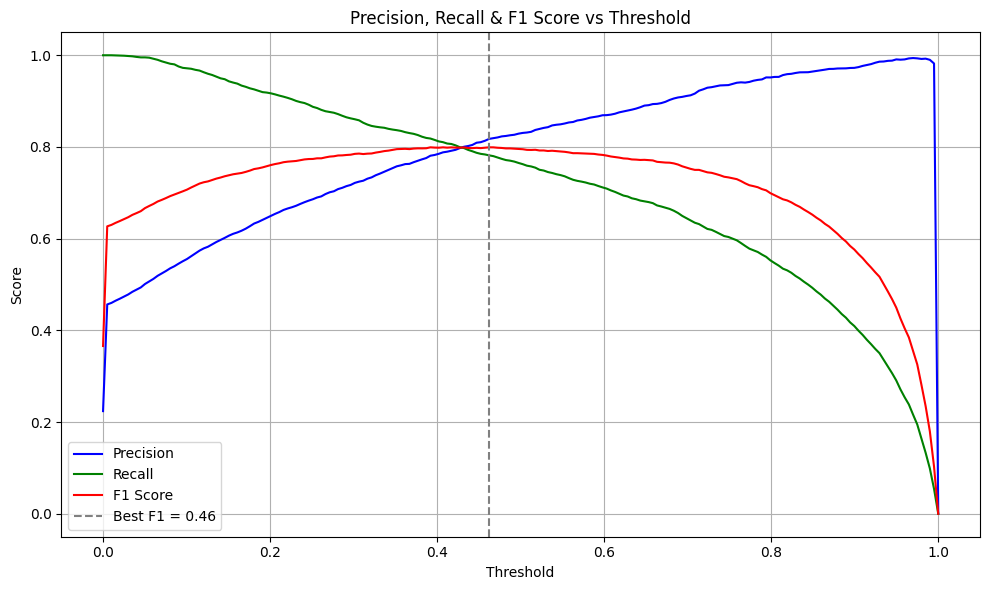

In [428]:
my_proba = my_lr.predict_proba(X_test_processed)
plot_roc_auc(y_test, my_proba, model_name="MyLogReg")
plot_metrics(y_test, my_proba)

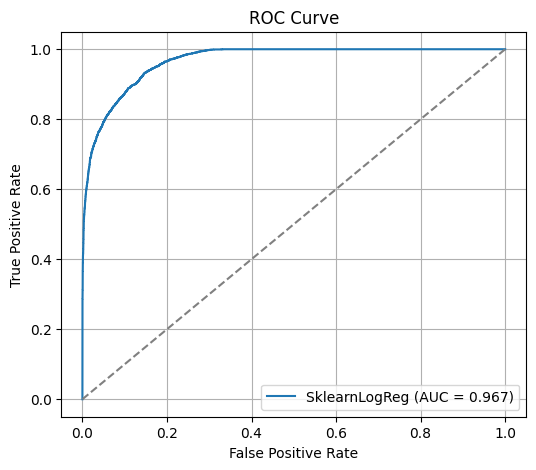

Optimal threshold for F1 Score: 0.44


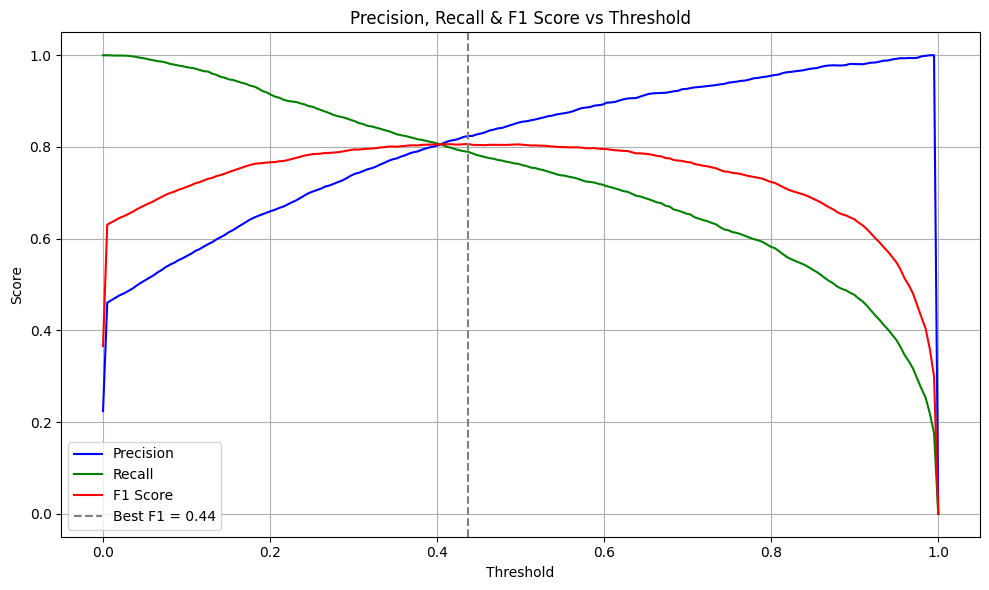

In [429]:
sk_proba = sk_lr.predict_proba(X_test_processed)[:, 1]
plot_roc_auc(y_test, sk_proba, model_name="SklearnLogReg")
plot_metrics(y_test, sk_proba)


=== Threshold: 0.46 ===
Confusion Matrix:
[[9942  535]
 [ 657 2366]]
Accuracy:  0.912
Precision: 0.816
Recall:    0.783
F1 Score:  0.799

=== Threshold: 0.44 ===
Confusion Matrix:
[[9894  583]
 [ 629 2394]]
Accuracy:  0.910
Precision: 0.804
Recall:    0.792
F1 Score:  0.798


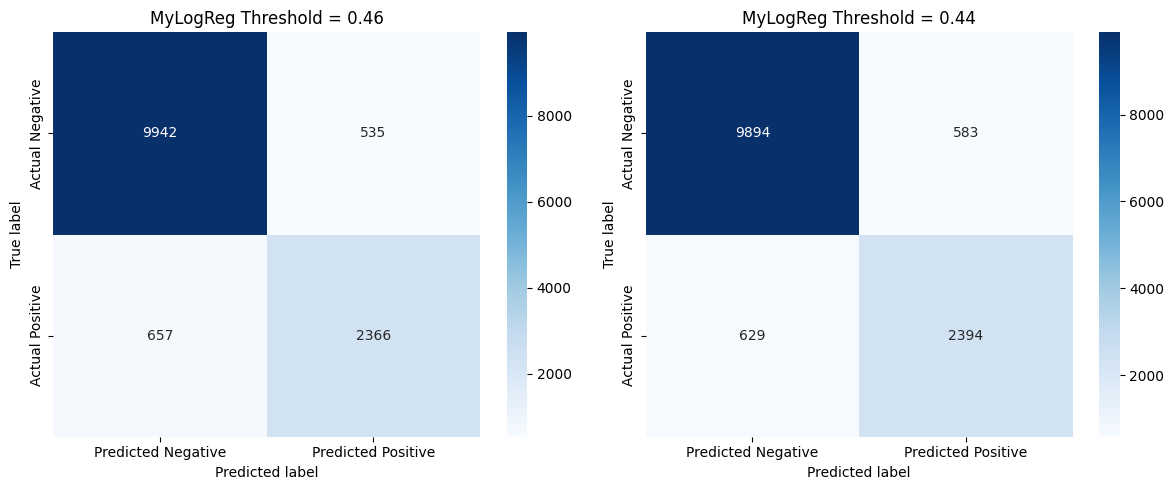


=== Threshold: 0.46 ===
Confusion Matrix:
[[10010   467]
 [  673  2350]]
Accuracy:  0.916
Precision: 0.834
Recall:    0.777
F1 Score:  0.805

=== Threshold: 0.44 ===
Confusion Matrix:
[[9967  510]
 [ 640 2383]]
Accuracy:  0.915
Precision: 0.824
Recall:    0.788
F1 Score:  0.806


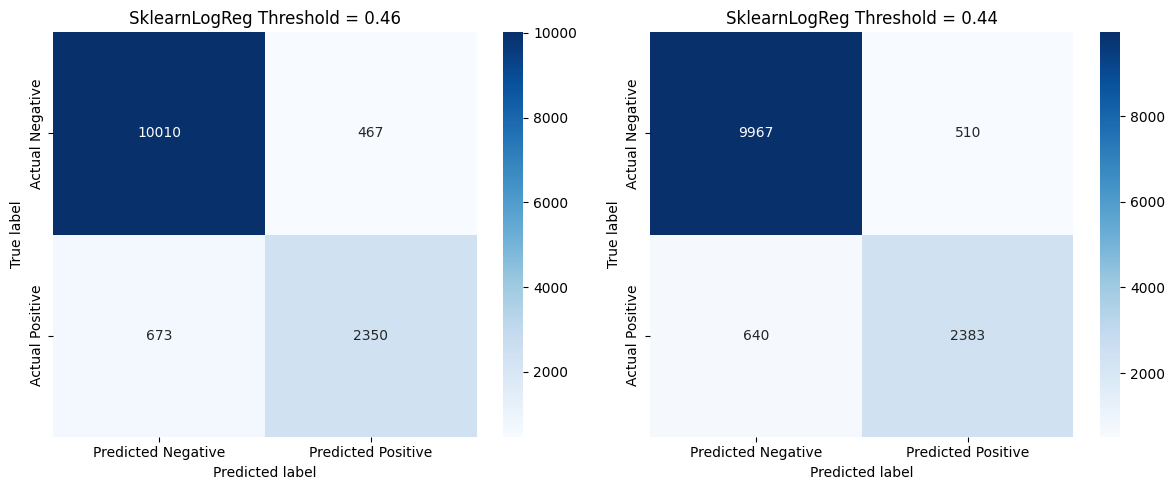

In [430]:
thresholds = [0.46, 0.44]
plot_confusion_matrix(y_test, my_proba, thresholds=thresholds, label="MyLogReg")
plot_confusion_matrix(y_test, sk_proba, thresholds=thresholds, label="SklearnLogReg")

## с учетом факторов

In [431]:
client_features = [
    "person_age",
    "person_gender",
    "person_education",
    "person_income",
    "person_emp_exp",
    "person_home_ownership",
]

product_features = [
    "loan_amnt",
    "loan_intent",
    "loan_int_rate",
    "loan_percent_income",
]

credit_history_features = [
    "cb_person_cred_hist_length",
    "credit_score",
    "previous_loan_defaults_on_file",
]

all_features = client_features + product_features + credit_history_features

In [432]:
X_train, y_train, X_test, y_test = create_split_data(train, test, target_col)

In [433]:
compare_data = {}

for group, features in {
    "client": client_features,
    "product": product_features,
    "credit": credit_history_features,
}.items():
    model, score, proba = build_model(
        X_train[features],
        y_train,
        X_test[features],
        y_test,
    )
    compare_data[group] = {"score": score, "proba": proba}

In [434]:
X_meta_train = pd.DataFrame(
    np.vstack(
        (
            compare_data["client"]["proba"],
            compare_data["product"]["proba"],
            compare_data["credit"]["proba"],
        )
    ).T,
    columns=["client", "product", "credit"],
)

_, meta_score, meta_proba = build_model(X_meta_train, y_test, X_meta_train, y_test)

compare_data["meta"] = {"score": meta_score, "proba": meta_proba}

In [435]:
_, full_score, full_proba = build_model(X_train, y_train, X_test, y_test)

compare_data["full"] = {"score": full_score, "proba": full_proba}

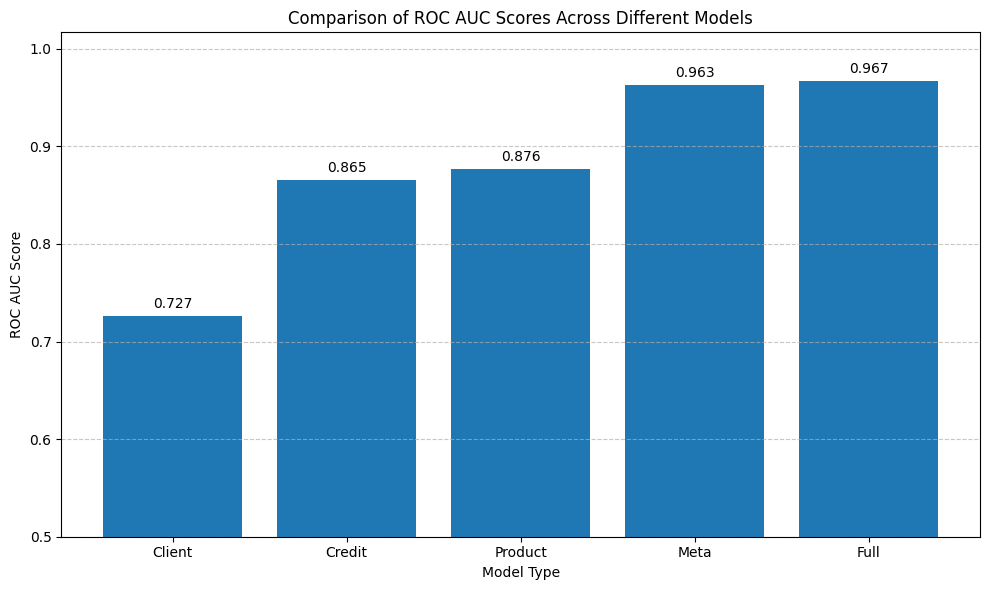

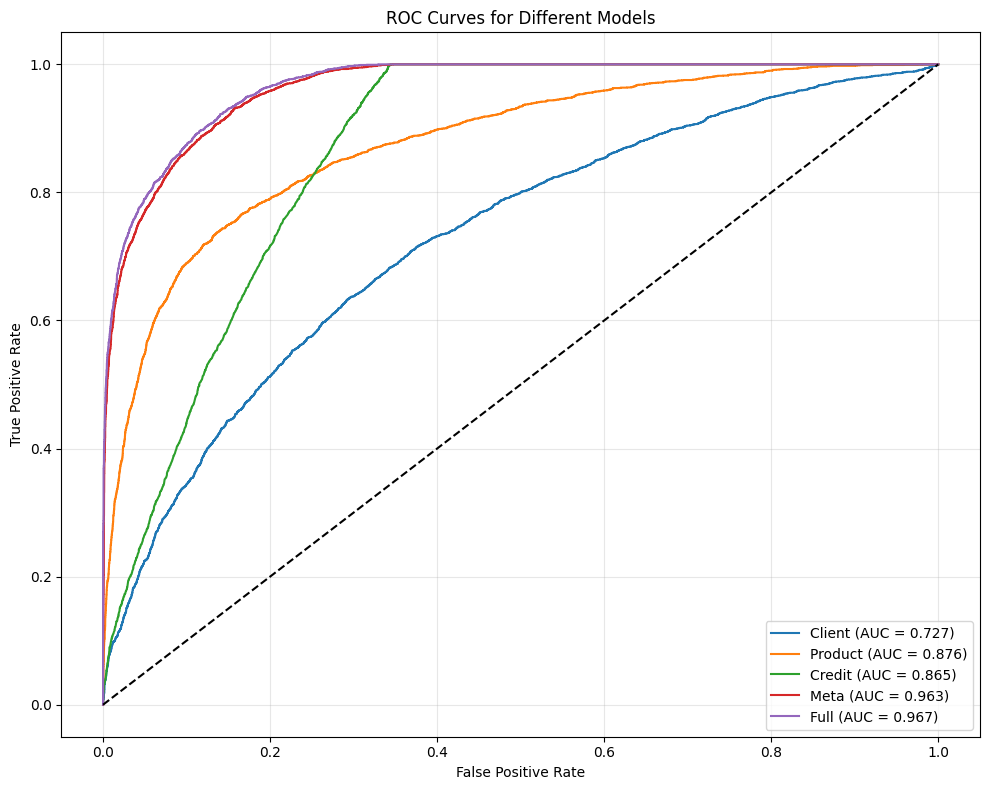

In [436]:
plt.figure(figsize=(10, 6))
scores = {k: v["score"] for k, v in compare_data.items()}

sorted_items = sorted(scores.items(), key=lambda x: x[1])
names = [item[0].capitalize() for item in sorted_items]
values = [item[1] for item in sorted_items]

bars = plt.bar(names, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.ylim(0.5, max(values) + 0.05)
plt.xlabel("Model Type")
plt.ylabel("ROC AUC Score")
plt.title("Comparison of ROC AUC Scores Across Different Models")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for name, data in compare_data.items():
    fpr, tpr, _ = roc_curve(y_test, data["proba"])
    plt.plot(fpr, tpr, label=f"{name.capitalize()} (AUC = {data['score']:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()